# Netflix Data Analysis

## Project Objective

The objective of this project is to perform exploratory data analysis on the Netflix dataset and identify trends related to content type, countries, ratings, genres, directors, and audience preferences.

##  Import libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Dataset Understanding

In [3]:
df.shape

(8807, 12)

In [4]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [5]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [6]:
df.isna().any()

show_id         False
type            False
title           False
director         True
cast             True
country          True
date_added       True
release_year    False
rating           True
duration         True
listed_in       False
description     False
dtype: bool

In [7]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
8802    False
8803    False
8804    False
8805    False
8806    False
Length: 8807, dtype: bool

## Data Cleaning

In [8]:
df.isnull().any()

show_id         False
type            False
title           False
director         True
cast             True
country          True
date_added       True
release_year    False
rating           True
duration         True
listed_in       False
description     False
dtype: bool

In [9]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [10]:
df.isnull().sum().idxmax()

'director'

In [11]:
df["country"] = df["country"].fillna("Unknown")

In [12]:
df["cast"]=df["cast"].fillna("Unknown")

In [13]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df["date_added"].isna().sum()

np.int64(98)

In [14]:
df["rating"]=df["rating"].fillna(df["rating"].mode()[0])

In [15]:
df.dropna(subset=["duration"])

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,Unknown,Unknown,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


## Date Conversion and Time-Based Analysis

In [16]:
df["date_added"].dtype

dtype('<M8[ns]')

In [17]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df["date_added"].head()


0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[ns]

In [18]:
df["date_added"].dtype

dtype('<M8[ns]')

In [19]:
df["date_added"].dt.year

0       2021.0
1       2021.0
2       2021.0
3       2021.0
4       2021.0
         ...  
8802    2019.0
8803    2019.0
8804    2019.0
8805    2020.0
8806    2019.0
Name: date_added, Length: 8807, dtype: float64

In [20]:
df["date_added"].dt.month

0        9.0
1        9.0
2        9.0
3        9.0
4        9.0
        ... 
8802    11.0
8803     7.0
8804    11.0
8805     1.0
8806     3.0
Name: date_added, Length: 8807, dtype: float64

In [21]:
df["date_added"].dt.year.value_counts()


date_added
2019.0    1999
2020.0    1878
2018.0    1625
2021.0    1498
2017.0    1164
2016.0     418
2015.0      73
2014.0      23
2011.0      13
2013.0      10
2012.0       3
2009.0       2
2008.0       2
2010.0       1
Name: count, dtype: int64

In [22]:
df["date_added"].dt.year.value_counts().idxmax()

np.float64(2019.0)

In [23]:
df.groupby(["date_added","type"]).size().unstack(fill_value=0)

type,Movie,TV Show
date_added,,
2008-01-01,1,0
2008-02-04,0,1
2009-05-05,1,0
2009-11-18,1,0
2010-11-01,1,0
...,...,...
2021-09-21,4,1
2021-09-22,3,6
2021-09-23,1,1


### Observations

The `date_added` column was converted from object datatype into datetime format to enable time-based analysis. Additional features such as year and month were extracted from the date column. This helped identify yearly content addition trends and understand Netflix's expansion pattern over time.


## Exploratory Data Analysis

In [24]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [25]:
df["type"].value_counts(normalize=True)*100

type
Movie      69.615079
TV Show    30.384921
Name: proportion, dtype: float64

Netflix should more focused on movies because the count and percentage of movies is much more than the tv show.

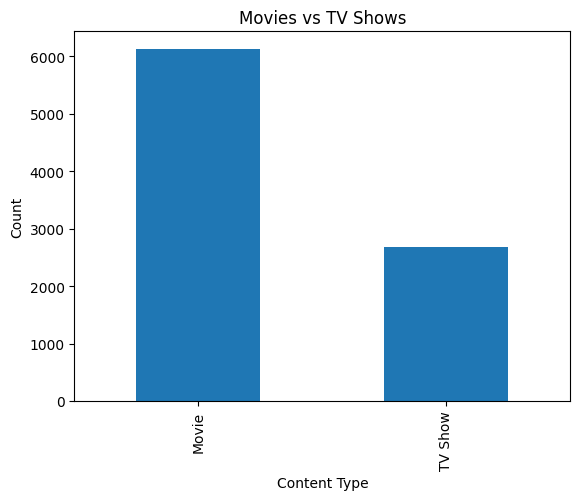

In [26]:
content_type = df['type'].value_counts()

content_type.plot(kind='bar')

plt.title('Movies vs TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Count')

plt.show()

### Insight

The graph shows that Movies are significantly higher in number compared to TV Shows on Netflix. This indicates that Netflix focuses more on movie content than TV Shows. However, TV Shows also represent an important portion of the platform’s content library.

## Country Analysis

In [27]:
countries = df["country"].dropna()
countries = countries.str.split(",")
countries = countries.explode()
countries = countries.str.strip()

top_10_country = countries.value_counts().head(10)
print(top_10_country)

country
United States     3690
India             1046
Unknown            831
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64


In [28]:
df["country"].value_counts().head(10)

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

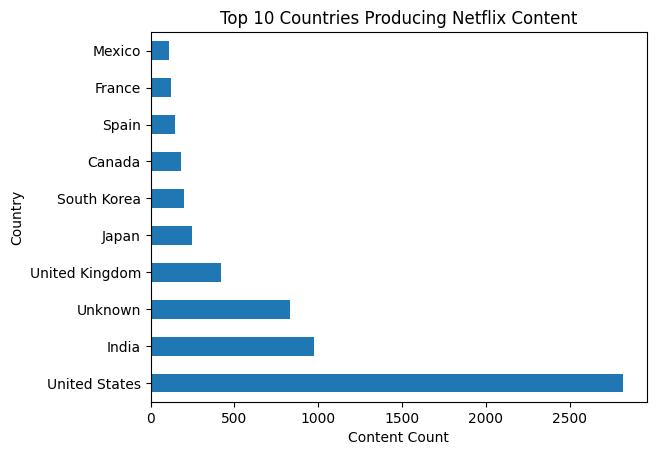

In [29]:
top_10_country = df["country"].value_counts().head(10)
top_10_country.plot(kind="barh")
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Content Count")
plt.ylabel("Country")
plt.show()

### Insight

The Top 10 countries account for a large share of the Netflix catalog, indicating a strong concentration of content production. The United States dominates the platform, while a few other countries contribute substantially. This pattern suggests that Netflix's content acquisition and production strategy is centered around major entertainment markets.

## Year-wise Content Trend Analysis

In [30]:
df["date_added"]=pd.to_datetime(df["date_added"],errors="coerce")
df["year"]=df["date_added"].dt.year
year_count=df["year"].value_counts()
high_content_addition=year_count.idxmax()
print(high_content_addition)

2019.0


In [31]:
yearly_content = df["year"].value_counts().sort_index()
print(yearly_content)

year
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64


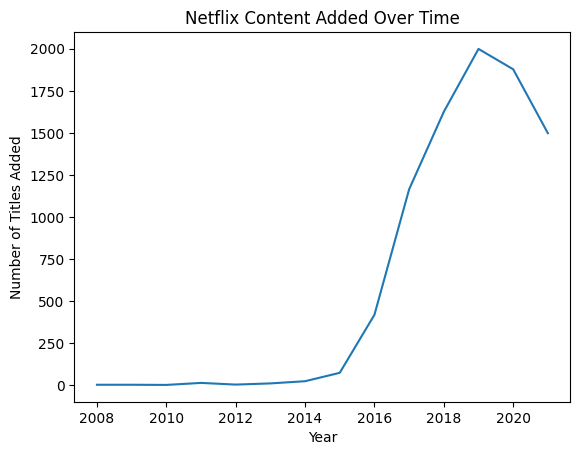

In [32]:
yearly_content.plot(kind="line")
plt.title("Netflix Content Added Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.show()

### Insight

The line graph shows that Netflix experienced rapid growth after 2015. Content additions increased significantly during the following years, indicating aggressive expansion of the platform's content library.

## Ratings Analysis

In [33]:
most_rating=df["rating"].value_counts().sort_index().idxmax()
print(most_rating)

TV-MA


### Insight

The analysis shows that TV-MA is the most common rating on Netflix. This indicates that a large portion of Netflix's content is designed for mature audiences rather than children. The dominance of TV-MA content suggests that Netflix primarily focuses on adult viewers and offers a wide range of mature entertainment options.

Netflix primarily targets adult audiences.

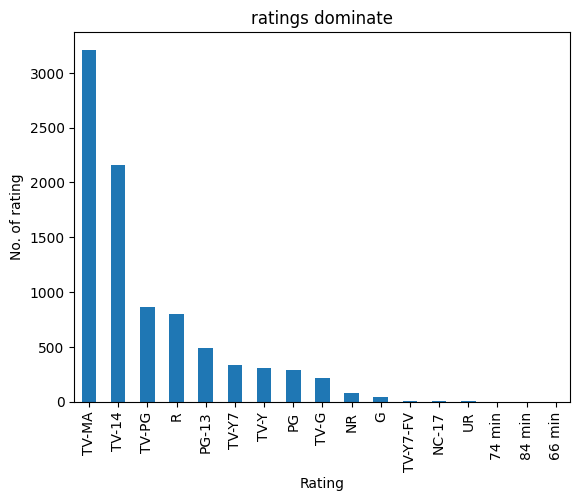

In [34]:
most_rating=df["rating"].value_counts()
most_rating.plot(kind="bar")
plt.title("ratings dominate")
plt.xlabel("Rating")
plt.ylabel("No. of rating")
plt.show()

### Insight

The analysis shows that TV-MA is the most common rating in the Netflix dataset. This indicates that a significant portion of Netflix's content is intended for mature audiences. The dominance of TV-MA titles suggests that adult viewers represent a major target audience on the platform.

## Director Analysis

In [35]:
df["director"].value_counts().idxmax()

'Rajiv Chilaka'

### Observation

Multiple directors are present in some rows of the dataset. Directors are separated by commas, so the column must be split and expanded before performing accurate director frequency analysis.

In [36]:
directors=df["director"].dropna()
directors=directors.str.split(",")
directors=directors.explode()
directors=directors.str.strip()
top_director=directors.value_counts().head(10)
print(top_director)

director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Martin Scorsese        12
Youssef Chahine        12
Jay Chapman            12
Name: count, dtype: int64


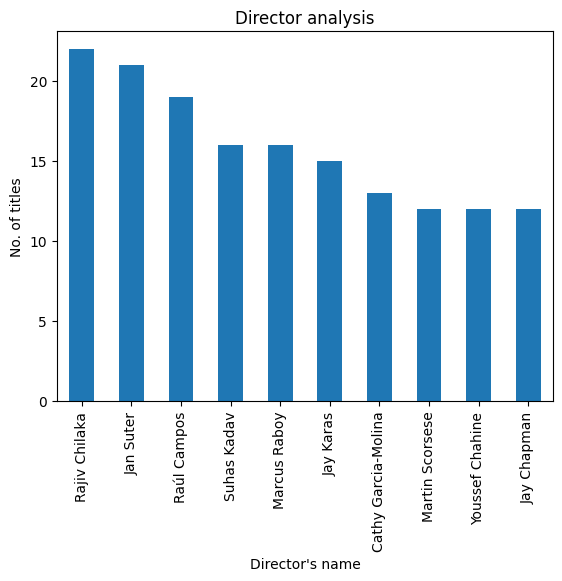

In [37]:
top_director.plot(kind="bar")
plt.title("Director analysis")
plt.xlabel("Director's name")
plt.ylabel("No. of titles")
plt.show()

### Insight

The analysis shows that Rajiv Chilaka has the highest number of titles on Netflix. The distribution of titles among directors suggests that Netflix features content from a diverse range of filmmakers rather than relying on a single director. However, a few directors contribute significantly more content than others, indicating a concentration of titles among top creators.

## Cast Analysis

In [38]:
df["cast"].value_counts().idxmax()

'Unknown'

### Observation

The cast column contains multiple actors in a single row, and the actors are separated by commas. Therefore, the column must be split and expanded before performing actor-level analysis.

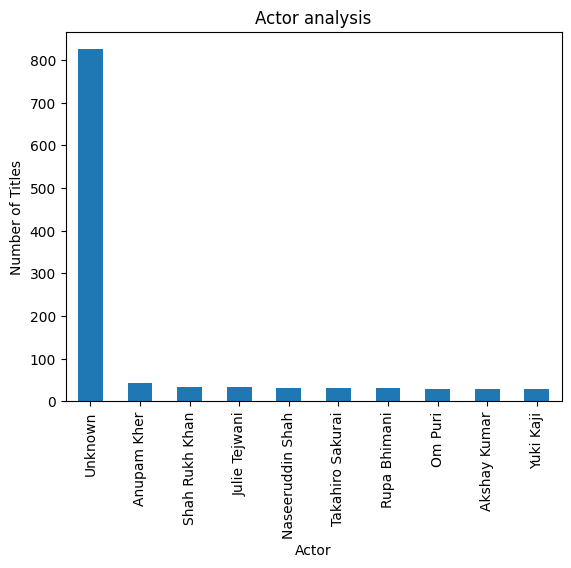

In [39]:
actors=df["cast"].dropna()
actors=actors.str.split(",")
actors=actors.explode()
actors=actors.str.strip()
top_actor=actors.value_counts().head(10)

top_actor.plot(kind="bar")
plt.title("Actor analysis")
plt.xlabel("Actor")
plt.ylabel("Number of Titles")
plt.show()

## Genre Analysis

In [40]:
df["listed_in"].value_counts().idxmax()

'Dramas, International Movies'

In [41]:
genre_df = df[['year', 'listed_in']].copy()
genre_df['listed_in'] = genre_df['listed_in'].str.split(',')
genre_df = genre_df.explode('listed_in')
genre_df['listed_in'] = genre_df['listed_in'].str.strip()
genre_growth = genre_df.groupby(['year', 'listed_in']).size().reset_index(name='count')
genre_growth.head(100)

,year,listed_in,count
0,2008.0,Dramas,1
1,2008.0,Independent Movies,1
2,2008.0,Stand-Up Comedy & Talk Shows,1
3,2008.0,Thrillers,1
4,2009.0,Dramas,1
...,...,...,...
95,2016.0,LGBTQ Movies,2
96,2016.0,Movies,12
97,2016.0,Music & Musicals,13
98,2016.0,Reality TV,5


### Insight

The genre analysis reveals that Netflix provides content across a broad range of genres. Popular categories such as Dramas, Movies, Romantic Movies, and Music & Musicals appear frequently throughout the dataset, highlighting Netflix's focus on offering diverse entertainment options to its global audience.

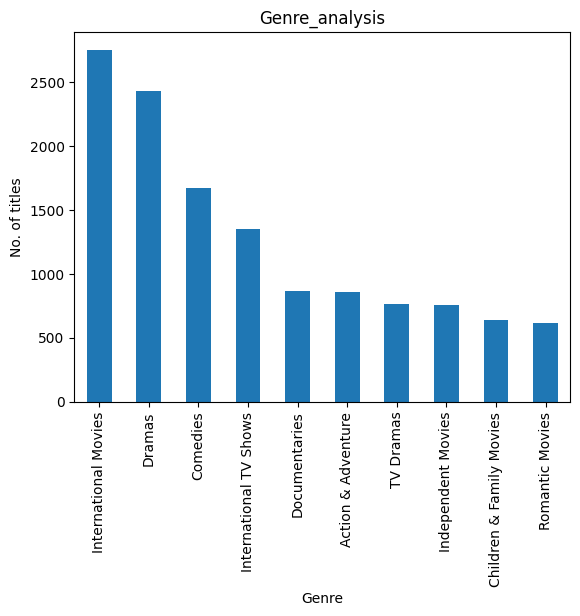

In [42]:
genre=df["listed_in"].dropna()
genre=genre.str.split(",")
genre=genre.explode()
genre=genre.str.strip()
top_genre=genre.value_counts().head(10)

top_genre.plot(kind="bar")
plt.title("Genre_analysis")
plt.xlabel("Genre")
plt.ylabel("No. of titles")
plt.show()

### Insight

The analysis shows that International Movies are the most common genre on Netflix, followed by Dramas, Comedies, and International TV Shows. This indicates that Netflix places a strong emphasis on global content and aims to serve audiences from different countries and cultural backgrounds. The popularity of Drama and Comedy genres also suggests that story-driven and entertainment-focused content forms a major part of Netflix's catalog.

## Duration Analysis

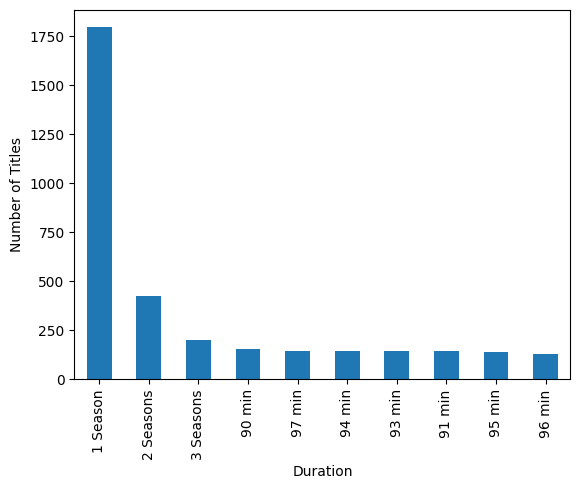

In [43]:
duration=df["duration"].dropna()

top_duration=duration.value_counts().head(10)
top_duration.plot(kind="bar")
plt.xlabel("Duration")
plt.ylabel("Number of Titles")
plt.show()


### Insight

The most frequent duration category on Netflix is 1 Season, followed by 2 Seasons and 3 Seasons. This suggests that the platform hosts a significant number of short-format TV shows rather than long-running series. Additionally, 90-minute movies are highly represented, indicating a preference for standard-length films that appeal to a broad audience.

## Business Insights

### 1. Is Netflix investing more in Movies or TV Shows?

The analysis shows that Movies significantly outnumber TV Shows on Netflix. This suggests that Netflix invests heavily in movie content while maintaining a smaller but important TV Show catalog.

### 2. Which countries are most important for Netflix?

The United States contributes the largest share of Netflix content, followed by countries such as India and other major entertainment markets. This indicates that Netflix relies heavily on a few key content-producing countries.

### 3. Has Netflix rapidly expanded in recent years?

The year-wise trend analysis shows a strong increase in content additions over time, especially after 2015. This suggests that Netflix experienced rapid expansion and significantly increased its content library in recent years.

### 4. What type of audience is Netflix targeting?

The dominance of the TV-MA rating indicates that Netflix primarily targets mature audiences. Although content exists for all age groups, adult-oriented content represents a large portion of the catalog.

### 5. Which genres are dominating?

International Movies, Dramas, and Comedies are among the most common genres on Netflix. This suggests that Netflix focuses on globally appealing and story-driven content.


## Conclusion

### What did I learn?

Through this project, I learned how to clean real-world data, handle missing values, perform exploratory data analysis (EDA), create visualizations, and extract meaningful insights from a dataset.

### What patterns did I discover?

* Movies are more common than TV Shows.
* Netflix content is concentrated in a few major countries.
* Content additions increased significantly over time.
* Mature-audience content dominates the platform.
* International Movies, Dramas, and Comedies are the most popular genres.
* Short-format TV Shows and standard-length movies are highly represented.

### What business insights did I find?

The analysis suggests that Netflix focuses on expanding its global content library through International Movies and popular entertainment genres. The platform relies heavily on major content-producing countries and primarily targets adult audiences. The strong growth in content additions over recent years highlights Netflix's strategy of continuously expanding its catalog to attract and retain viewers worldwide.
